# Facebook GCD-11 walkthrough using `orbit-count`

This notebook is a Python-native walkthrough of **Graphlet Correlation Distance (GCD-11)** using the
`orbit-count` package instead of an external `orca` executable.

The goal is tactile understanding:

1. load the Facebook ground-truth graph,
2. compute node orbit counts up to 4-node graphlets,
3. select the 11 non-redundant orbits used in GCD-11,
4. build the graphlet correlation matrix (GCM),
5. compare the graph to a perturbed version with GCD-11.

## Metric definition

Let $X_G\in\mathbb{R}^{|V|\times 11}$ be the node-by-orbit matrix for the 11 non-redundant graphlet orbits used in GCD-11.
For orbit columns $a$ and $b$, define

$$\mathrm{GCM}_{ab}(G)=\rho_s\big(X_G[:,a], X_G[:,b]\big),$$

where $\rho_s$ is Spearman's rank correlation.

Then for graphs $G$ and $H$,

$$\mathrm{GCD}_{11}(G,H)=
\left\|
\operatorname{vec}_{\triangle}(\mathrm{GCM}(G))-
\operatorname{vec}_{\triangle}(\mathrm{GCM}(H))
\right\|_2,$$

where $\operatorname{vec}_{\triangle}(\cdot)$ extracts the entries strictly above the diagonal.

**Interpretation:** summarize how graphlet roles co-vary across nodes in each graph, then measure how different those summaries are.
Lower values mean the two graphs are more similar in local topology.

In [1]:
from pathlib import Path
import sys

# Expected if this notebook is copied into cluster_analysis/notebooks
PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

PosixPath('/data/Sean/edge-probability-graph-model')

In [2]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

try:
    import orbit_count
except ImportError as e:
    raise ImportError(
        "This notebook requires orbit-count. Install with: pip install orbit-count"
    ) from e

from metrics import load_graph, gcm11_from_orbits, gcd11, GCD11_ORBITS

## Load the Facebook graph

In [3]:
facebook_path = (PROJECT_ROOT / "data" / "gt_txt" / "facebook.txt")
G = load_graph(facebook_path)

print(f"Loaded graph: {facebook_path.name}")
print(f"Nodes: {G.number_of_nodes():,}")
print(f"Edges: {G.number_of_edges():,}")

Loading graph: 88234it [00:00, 721430.66it/s]


Loaded graph: facebook.txt
Nodes: 4,039
Edges: 88,234


## Compute orbit counts with `orbit-count`

For graphlets up to size 4, the full node orbit matrix has **15 columns**.
GCD-11 then keeps the 11 non-redundant orbit columns.

We make the node ordering explicit so that rows in the matrix correspond to sorted node ids.

In [4]:
node_list = list(sorted(G.nodes()))
orbits = orbit_count.node_orbit_counts(G, graphlet_size=4, node_list=node_list)
orbits = np.asarray(orbits, dtype=np.int64)

print("Orbit matrix shape:", orbits.shape)
print("Expected: (n_nodes, 15)")
print("GCD-11 non-redundant orbit columns:", GCD11_ORBITS)

Orbit matrix shape: (4039, 15)
Expected: (n_nodes, 15)
GCD-11 non-redundant orbit columns: [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11]


### Inspect the first few rows of the 15-orbit matrix

In [5]:
orbit_df = pd.DataFrame(orbits, index=node_list)
orbit_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,347,1194,57512,2519,12269,408520,519123,6099427,12,29525,4548,749961,16,43437,10740
1,17,689,79,57,6470,3144,56552,144,153,4317,6162,294,706,165,77
2,10,707,8,37,7481,341,59737,0,123,4976,3844,16,966,32,72
3,9,440,14,22,3063,262,55835,11,1,3137,2982,17,137,31,25
4,35,2452,226,369,38509,14004,524711,653,1086,38515,55392,1726,5900,2047,2119


## Restrict to the 11 non-redundant orbits used by GCD-11

In [6]:
orbits11 = orbits[:, GCD11_ORBITS]
orbits11_df = pd.DataFrame(
    orbits11,
    index=node_list,
    columns=[f"orbit_{i}" for i in GCD11_ORBITS],
)
orbits11_df.head()

,orbit_0,orbit_1,orbit_2,orbit_4,orbit_5,orbit_6,orbit_7,orbit_8,orbit_9,orbit_10,orbit_11
0,347,1194,57512,12269,408520,519123,6099427,12,29525,4548,749961
1,17,689,79,6470,3144,56552,144,153,4317,6162,294
2,10,707,8,7481,341,59737,0,123,4976,3844,16
3,9,440,14,3063,262,55835,11,1,3137,2982,17
4,35,2452,226,38509,14004,524711,653,1086,38515,55392,1726


## Build the graphlet correlation matrix (GCM)

Each entry is the Spearman correlation between two orbit columns across all nodes.

In [7]:
GCM = gcm11_from_orbits(orbits)
gcm_df = pd.DataFrame(
    GCM,
    index=[f"orbit_{i}" for i in GCD11_ORBITS],
    columns=[f"orbit_{i}" for i in GCD11_ORBITS],
)
gcm_df.round(3)

,orbit_0,orbit_1,orbit_2,orbit_4,orbit_5,orbit_6,orbit_7,orbit_8,orbit_9,orbit_10,orbit_11
orbit_0,1.000,0.835,0.982,0.819,0.952,0.319,0.959,0.942,0.626,0.955,0.989
orbit_1,0.835,1.000,0.825,0.940,0.892,0.702,0.806,0.898,0.904,0.940,0.833
orbit_2,0.982,0.825,1.000,0.815,0.975,0.323,0.993,0.939,0.610,0.935,0.996
orbit_4,0.819,0.940,0.815,1.000,0.899,0.585,0.795,0.905,0.844,0.889,0.822
orbit_5,0.952,0.892,0.975,0.899,1.000,0.424,0.967,0.962,0.705,0.944,0.971
orbit_6,0.319,0.702,0.323,0.585,0.424,1.000,0.320,0.394,0.794,0.530,0.323
orbit_7,0.959,0.806,0.993,0.795,0.967,0.320,1.000,0.918,0.589,0.911,0.982
orbit_8,0.942,0.898,0.939,0.905,0.962,0.394,0.918,1.000,0.712,0.944,0.945
orbit_9,0.626,0.904,0.610,0.844,0.705,0.794,0.589,0.712,1.000,0.783,0.621
orbit_10,0.955,0.940,0.935,0.889,0.944,0.530,0.911,0.944,0.783,1.000,0.944


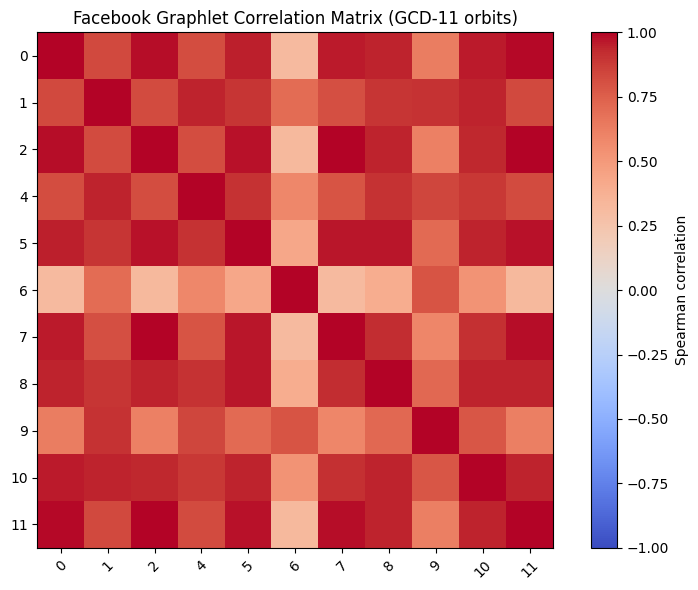

In [8]:
plt.figure(figsize=(8, 6))
plt.imshow(GCM, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Spearman correlation")
plt.xticks(range(len(GCD11_ORBITS)), [str(i) for i in GCD11_ORBITS], rotation=45)
plt.yticks(range(len(GCD11_ORBITS)), [str(i) for i in GCD11_ORBITS])
plt.title("Facebook Graphlet Correlation Matrix (GCD-11 orbits)")
plt.tight_layout()
plt.show()

## A small subgraph example

To make the orbit counts more tangible, we take a modest ego subgraph and compute its orbit-count matrix.
This is not for the final GCD metric on the full graph; it is just for inspection.

In [9]:
degrees = dict(G.degree())
candidate_center = min(
    [u for u, d in degrees.items() if 8 <= d <= 20],
    key=lambda u: abs(degrees[u] - 12)
)

H = nx.ego_graph(G, candidate_center, radius=1)
print("Chosen center:", candidate_center)
print("Ego nodes:", H.number_of_nodes())
print("Ego edges:", H.number_of_edges())

Chosen center: 3429
Ego nodes: 13
Ego edges: 60


In [10]:
node_list_H = list(sorted(H.nodes()))
orbits_H = orbit_count.node_orbit_counts(H, graphlet_size=4, node_list=node_list_H)
orbits_H = np.asarray(orbits_H, dtype=np.int64)

pd.DataFrame(
    orbits_H[:, GCD11_ORBITS],
    index=node_list_H,
    columns=[f"orbit_{i}" for i in GCD11_ORBITS],
).head(15)

,orbit_0,orbit_1,orbit_2,orbit_4,orbit_5,orbit_6,orbit_7,orbit_8,orbit_9,orbit_10,orbit_11
0,12,0,18,0,0,0,10,0,0,0,45
47,9,16,1,0,3,11,0,0,0,43,0
247,10,8,3,0,2,3,0,0,0,44,2
358,3,26,0,6,0,22,0,0,78,2,0
469,10,8,3,0,2,3,0,0,0,44,2
957,11,3,9,0,1,0,2,0,0,23,16
1114,8,21,0,11,0,8,0,0,13,35,0
1347,5,32,0,4,0,26,0,0,61,10,0
2258,11,8,14,0,11,0,7,0,0,13,31
2469,11,3,9,0,1,0,2,0,0,23,16


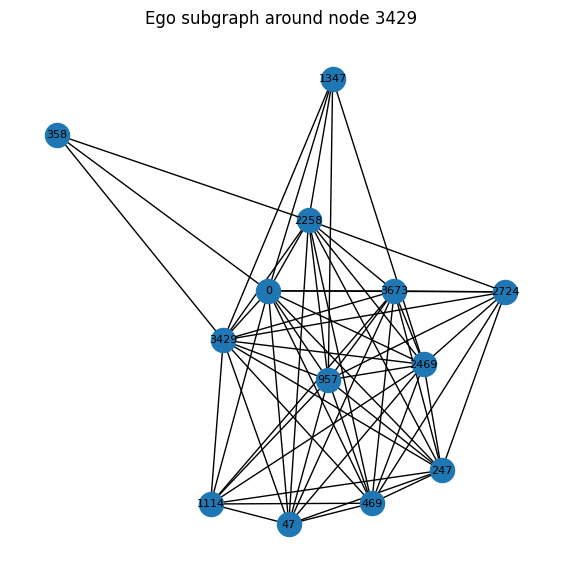

In [11]:
plt.figure(figsize=(7, 7))
pos = nx.spring_layout(H, seed=7)
nx.draw_networkx(H, pos=pos, node_size=300, font_size=8)
plt.title(f"Ego subgraph around node {candidate_center}")
plt.axis("off")
plt.show()

## Compute GCD-11 against a perturbed version of Facebook

For a simple demonstration, we create a perturbed graph by rewiring a small fraction of edges while preserving
the total number of edges.

In [12]:
rng = np.random.default_rng(7)

Gp = G.copy()
edges = list(Gp.edges())
non_edges = list(nx.non_edges(Gp))

n_swaps = min(1000, len(edges), len(non_edges))
remove_idx = rng.choice(len(edges), size=n_swaps, replace=False)
add_idx = rng.choice(len(non_edges), size=n_swaps, replace=False)

for idx in sorted(remove_idx, reverse=True):
    u, v = edges[idx]
    if Gp.has_edge(u, v):
        Gp.remove_edge(u, v)

for idx in add_idx:
    u, v = non_edges[idx]
    if not Gp.has_edge(u, v):
        Gp.add_edge(u, v)

print("Perturbed graph nodes:", Gp.number_of_nodes())
print("Perturbed graph edges:", Gp.number_of_edges())

Perturbed graph nodes: 4039
Perturbed graph edges: 88234


In [13]:
dist = gcd11(G, Gp)
print(f"GCD-11(Facebook, perturbed Facebook) = {dist:.6f}")

GCD-11(Facebook, perturbed Facebook) = 0.038089


## Interpretation

GCD-11 is broader than any single clustering statistic. Instead of measuring only one pattern such as triangle closure or 4-clique density, it summarizes how different small graphlet roles co-vary across nodes and then compares those summaries between graphs.

A low GCD-11 value means the two graphs have similar local topological organization, even if that similarity is not captured by any one scalar metric. A high GCD-11 value means their local wiring patterns differ in a more structural way.

For realism testing later, matching GCD-11 means reproducing the overall local topology of the real graph, not just matching one specific motif count or clustering coefficient.